## Clima y precio: ¿hay una relación?

**Fase 3 · limpieza y cruzamiento (guía).** Última pieza del rompecabezas: ¿el clima tiene algo que ver con los precios? Se calculan las anomalías anuales frente a la normal histórica y se correlacionan con la variación del precio en el cuadro maestro.

In [1]:
import sys
from pathlib import Path
_ROOT = Path.cwd()
while not any((_ROOT / c).exists() for c in ['db', 'data']) and _ROOT != _ROOT.parent:
    _ROOT = _ROOT.parent
sys.path.insert(0, str(_ROOT / 'script'))
from proyecto import graficos
display(graficos.fig_fases())

<Figure size 1344x364 with 1 Axes>

## 1. Buscar la raíz del proyecto

In [2]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

PROYECTO = Path.cwd()
while not any((PROYECTO / c).exists() for c in ['db', 'data']) and PROYECTO != PROYECTO.parent:
    PROYECTO = PROYECTO.parent

sys.path.insert(0, str(PROYECTO / 'script'))
from proyecto import config
from proyecto import (cargar, limpiar, diagnostico, transformaciones, cruces,
                      indicadores, validacion, graficos)

def presentar(fig):
    display(fig)

print('raiz del proyecto:', PROYECTO.name)
print('fuentes en data/crudo:', [p.name for p in config.DATA_CRUDO.glob('*.csv')])

raiz del proyecto: mineria
fuentes en data/crudo: ['Average_UK_houseprices_and_salary.csv', 'Income_by_age_and_gender.csv', 'MET_Office_Weather_Data.csv', 'UK_Mortgage_Rate.csv']


## 2. De lecturas mensuales a anomalías anuales

Una estación es 'más lluviosa' o 'más cálida' cuando se aleja de su propia normal. Por eso la anomalía se calcula contra el promedio histórico 1931-2020 de esa estación, y luego se promedia por región.

In [3]:
c = cargar.cargar_clima()
c_limpio, _ = limpiar.limpiar_clima(c)
anual = transformaciones.clima_anual(c_limpio)
anom_nac, anom_reg = transformaciones.anomalias_climaticas(anual)
display(anom_nac)
print('estaciones por region en el cruce:')
display(pd.Series(config.ESTACION_REGION).value_counts().to_frame('estaciones'))

,anio,tmax_anom,tmin_anom,lluvia_anom,sol_anom,af_anom
0,1853.0,-1.125021,-1.082391,-6.416863,NaN,-4.395833
1,1854.0,0.133312,-0.899057,-8.141863,NaN,-15.895833
2,1855.0,-1.326752,-1.313539,-6.423540,NaN,12.322869
3,1856.0,-0.385085,-0.476039,-5.009399,NaN,-4.677131
4,1857.0,0.606581,0.344795,-1.026065,NaN,-9.677131
...,...,...,...,...,...,...
163,2016.0,0.715796,0.611864,-0.174387,-5.663470,-6.193313
164,2017.0,0.946469,0.947571,-1.140674,-6.385026,-8.344828
165,2018.0,1.029171,0.662318,-1.441053,6.420573,-4.526646
166,2019.0,1.009686,0.777415,8.139334,-2.026566,-10.738767


estaciones por region en el cruce:


,estaciones
Wales,4
South West,4
South East,4
Yorkshire and The Humber,3
East of England,2
North West,2
West Midlands,2
North East,1
London,1
East Midlands,1


## 3. Lluvia nacional en la ventana de estudio

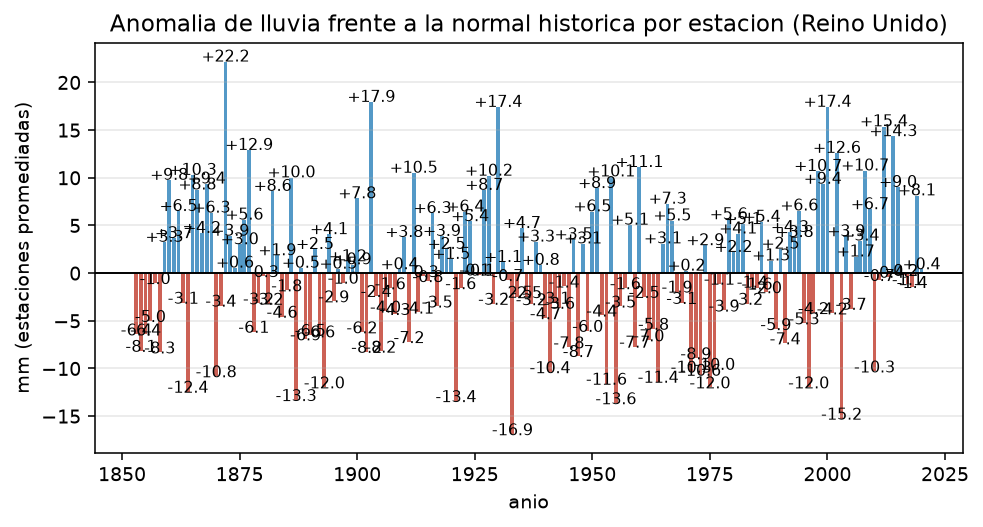

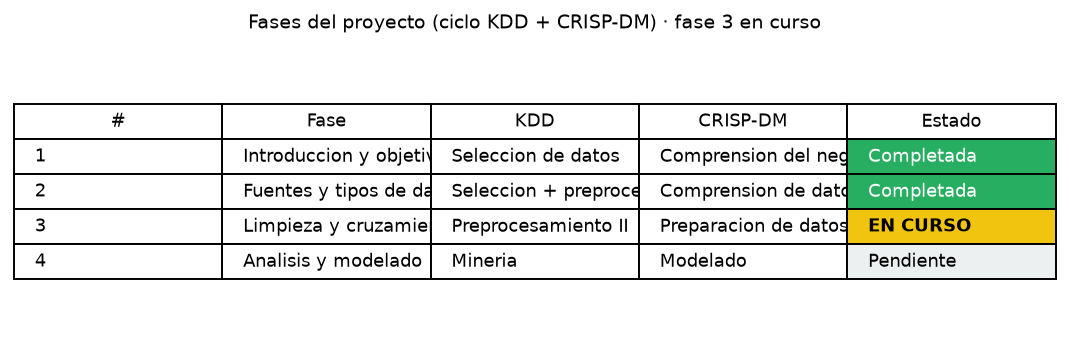

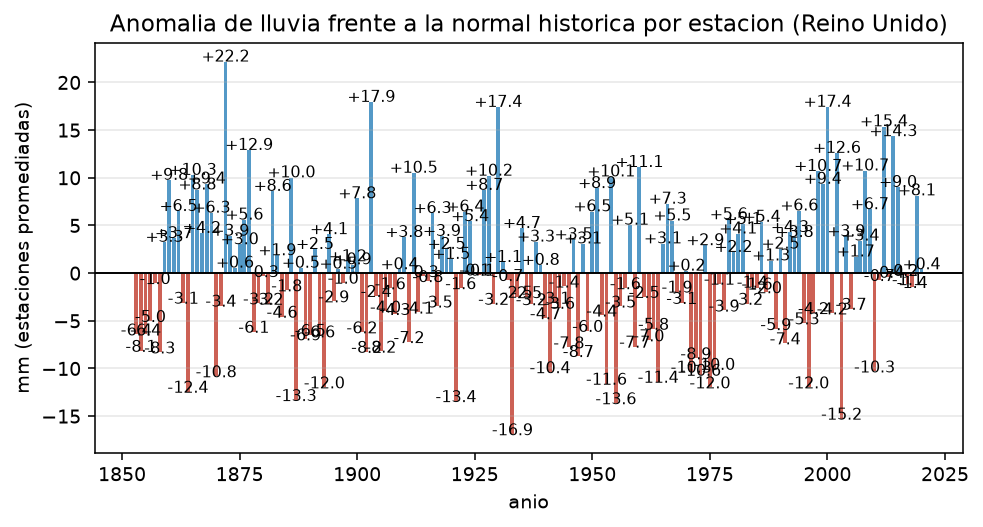

In [4]:
presentar(graficos.fig_anomalia_lluvia(anom_nac))

## 4. Cruzar clima con precios (el maestro)

In [5]:
t = cargar.cargar_precios_limpios()
precios_region = transformaciones.agregado_precios_region(t)
st = transformaciones.serie_salario_joven(cargar.cargar_precios_salario(),
          transformaciones.salario_joven(cargar.cargar_ingreso_edad(),
                                            cargar.cargar_precios_salario())[1])
maestro = cruces.cruce_maestro(precios_region, st, anom_reg)
display(maestro[['anio', 'region', 'precio_mediana', 'precio_var_pct', 'lluvia_anom', 'tmax_anom', 'af_anom']])

,anio,region,precio_mediana,precio_var_pct,lluvia_anom,tmax_anom,af_anom
0,2015,East Midlands,157500.0,NaN,-6.180180,1.000338,-18.459459
1,2016,East Midlands,165000.0,4.761905,3.936486,0.725338,-12.459459
2,2017,East Midlands,178000.0,7.878788,-1.830180,0.942005,-14.459459
3,2018,East Midlands,185500.0,4.213483,-0.996847,1.267005,-8.459459
4,2019,East Midlands,190000.0,2.425876,16.253153,1.083671,-21.459459
5,2020,East Midlands,202500.0,6.578947,-11.946847,0.650338,-34.459459
6,2015,East of England,235000.0,NaN,-5.391098,0.885883,-17.955113
7,2016,East of England,255000.0,8.510638,-4.332765,0.677550,-12.455113
8,2017,East of England,275000.0,7.843137,4.550568,0.685883,-15.955113
9,2018,East of England,280000.0,1.818182,-4.399432,1.085883,-15.455113


## 5. Correlaciones con el precio

In [6]:
corr = indicadores.correlacion_clima_precio(maestro)
display(corr.round(3))
print('lectura: correlaciones negativas = a mayor anomalia (mas lluvia/calor), menor variacion del precio')

,clima,pearson,n
0,lluvia_anom,-0.241,50
1,tmax_anom,-0.388,50
2,tmin_anom,-0.399,50
3,af_anom,-0.145,50
4,sol_anom,0.238,35


lectura: correlaciones negativas = a mayor anomalia (mas lluvia/calor), menor variacion del precio


## 6. La dispersión entre lluvia y precio

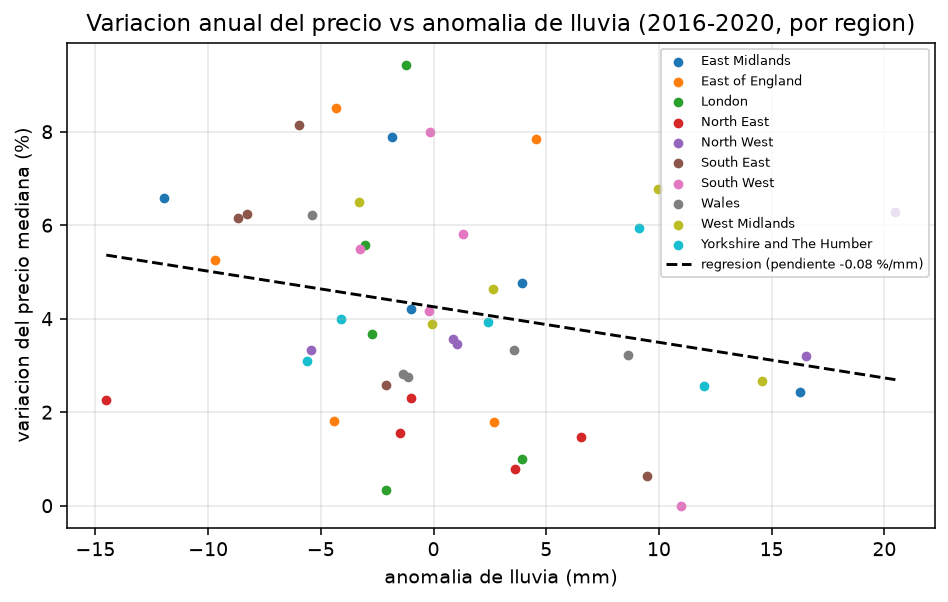

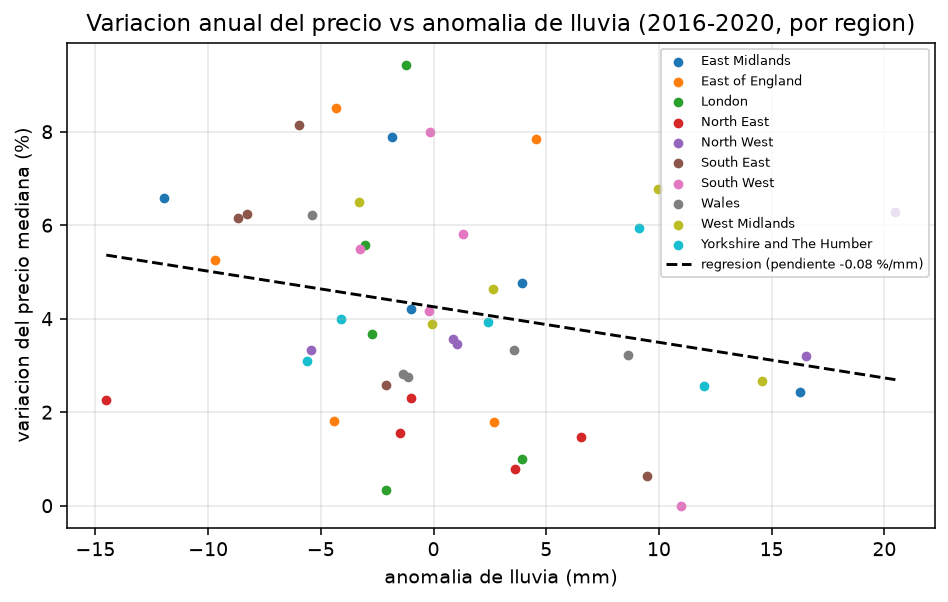

In [7]:
presentar(graficos.fig_clima_precio(maestro))

## A modo de lectura

Las correlaciones son **débiles y negativas** (lluvia -0,24; temperatura máxima -0,39; mínima -0,40): cuando el año estuvo por encima de su normal (más lluvia o más calor), la suba del precio tendió a ser menor, pero la relación es demasiado baja para explicar los niveles de precio por región. Lo que manda, más bien, es el binomio salario-tasa-oferta del cuaderno 04.

## Cierre del cuaderno

Con esto queda cerrado el avance: **años de salario (F1 + F4) · hipoteca 2022 (F2) · clima marginal (F3)**. El cuadro maestro completo queda en `data/integrado/maestro_joven_uk.parquet`.